# **CAS DATASET PROCESSING + EDA**

## **Load Data**

In [29]:
from datasets import load_dataset


dataset = load_dataset("rntc/deft-cas-cliniques-ner")

df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

In [30]:
df_train.head(3)

,id,tokens,ner_tags
0,57,"[Mme, Lau, ., ,, 50, ans, ,, sans, antécédent,...","[81, 0, 0, 0, 83, 84, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,205,"[C, ., F, ,, fille, de, 15, ans, a, présenté, ...","[0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, 0, 0, 95,..."
2,320,"[Nous, décrivons, ci, -, dessous, le, cas, d, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 81, 0, 83, 84, ..."


In [31]:
df_test.head(3)

,id,tokens,ner_tags
0,121,"[Monsieur, A, ., K, ., ,, âgé, de, 53, ans, ,,...","[81, 0, 0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, 0, ..."
1,332,"[Une, jeune, femme, ,, Mlle, X, ,, âgée, de, 2...","[0, 0, 81, 0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, ..."
2,40,"[V, ., ., ,, âgé, de, 32, ans, a, consulté, po...","[0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, 0, 23, 24,..."


## **Full Example of the Dataset**

**Example "tokens" of 1st row**

In [32]:
df_train.iloc[0,1]

array(['Mme', 'Lau', '.', ',', '50', 'ans', ',', 'sans', 'antécédent',
       'particulier', ',', 'a', 'été', 'admise', 'au', 'déchoquage',
       'suite', 'à', 'une', 'chute', 'de', '12', 'mètres', ',', 'par',
       'défénestration', ',', 'avec', 'réception', 'ventrale', '.',
       'Elle', 'présentait', 'un', 'coma', 'Glasgow', '4', ',', 'une',
       'hématurie', 'macroscopique', 'et', 'un', 'choc', 'hémorragique',
       'nécessitant', 'la', 'transfusion', 'de', '12', 'culots',
       'globulaires', 'et', 'de', '6', 'PFC', '(', 'Plasma', 'frais',
       'congelé', ')', '.', 'Le', 'bilan', 'radiologique', 'retrouvait',
       'de', 'multiples', 'lésions', ',', 'dont', 'aucunes', 'n', '’',
       'ont', 'nécessitées', 'une', 'intervention', 'chirurgicale', 'en',
       'urgence', ',', 'au', 'niveau', 'rénal', 'l', '’', 'uroscanner',
       'trouvait', 'une', 'hypoperfusion', 'complète', 'du', 'rein',
       'droit', ',', 'avec', 'une', 'artère', 'rénale', 'suivie', 'sur',
       '2c

**Example "ner_tags" of 1st row**

In [33]:
df_train.iloc[0,2]

array([81,  0,  0,  0, 83, 84,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, 95, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96, 96,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0

In [34]:
ner_dict = dataset["train"].features["ner_tags"].feature.names
print(ner_dict)
len(ner_dict)

['O', 'B-infections', 'I-infections', 'B-virales', 'I-virales', 'B-parasitaires', 'I-parasitaires', 'B-tumeur', 'I-tumeur', 'B-osteomusculaires', 'I-osteomusculaires', 'B-digestif', 'I-digestif', 'B-stomatognathique', 'I-stomatognathique', 'B-respiratoire', 'I-respiratoire', 'B-ORL', 'I-ORL', 'B-nerveux', 'I-nerveux', 'B-oeil', 'I-oeil', 'B-homme', 'I-homme', 'B-femme', 'I-femme', 'B-cardiovasculaires', 'I-cardiovasculaires', 'B-hemopathies', 'I-hemopathies', 'B-genetique', 'I-genetique', 'B-peau', 'I-peau', 'B-nutritionnelles', 'I-nutritionnelles', 'B-endocriniennes', 'I-endocriniennes', 'B-immunitaire', 'I-immunitaire', 'B-environnement', 'I-environnement', 'B-animal', 'I-animal', 'B-etatsosy', 'I-etatsosy', 'B-professionnelles', 'I-professionnelles', 'B-chimiques', 'I-chimiques', 'B-blessures', 'I-blessures', 'B-pathologie', 'I-pathologie', 'B-sosy', 'I-sosy', 'B-examen', 'I-examen', 'B-valeur', 'I-valeur', 'B-traitement', 'I-traitement', 'B-substance', 'I-substance', 'B-dose', 'I-d

119

**Example of NER Dictionnary on 1st row**

In [35]:
print(ner_dict[97])

B-issue


In [36]:
print(df_train.iloc[0,2][4:6])
print(df_train.iloc[0,1][4:6])
print((ner_dict[83], ner_dict[84]))

[83 84]
['50' 'ans']
('B-age', 'I-age')


## **Preprocessing (for EDA)**

**Combine train and test Datasets**

In [37]:
import pandas as pd

df = pd.concat([df_train, df_test])
df

,id,tokens,ner_tags
0,57,"[Mme, Lau, ., ,, 50, ans, ,, sans, antécédent,...","[81, 0, 0, 0, 83, 84, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,205,"[C, ., F, ,, fille, de, 15, ans, a, présenté, ...","[0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, 0, 0, 95,..."
2,320,"[Nous, décrivons, ci, -, dessous, le, cas, d, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 81, 0, 83, 84, ..."
3,530,"[Le, dernier, cas, concerne, un, homme, de, 42...","[0, 0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, 0, 0, ..."
4,25,"[Mme, K, ., K, ., ., ., ,, 33, ans, a, été, re...","[81, 0, 0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, 0, ..."
...,...,...,...
139,133,"[Il, s, ’, agit, d, ’, une, femme, de, 56, ans...","[0, 0, 0, 0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, ..."
140,293,"[Madame, B, ., M, ., ,, âgée, de, 47, ans, ,, ...","[81, 0, 0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, 0, ..."
141,42,"[Il, s, ’, agit, d, ’, une, patiente, âgée, de...","[0, 0, 0, 0, 0, 0, 0, 81, 0, 0, 83, 84, 0, 0, ..."
142,109,"[Un, homme, âgé, de, 19, ans, a, été, admis, d...","[0, 81, 0, 0, 83, 84, 0, 0, 0, 0, 0, 0, 0, 95,..."


**Retrieve original text from "tokens"**

In [38]:
import re

def retrieve_text(tokens):
    text = " ".join(tokens)

    # remove space before punctuation
    text = re.sub(r"\s+([-’'.,;:!?])", r"\1", text)

    # remove space after apostrophe (CRITICAL FIX for French)
    text = re.sub(r"([’'-])\s+", r"\1", text)

    return text
        
df["original_text"] = df["tokens"].apply(retrieve_text)
df["original_text"]

0      Mme Lau., 50 ans, sans antécédent particulier,...
1      C. F, fille de 15 ans a présenté pendant 3 moi...
2      Nous décrivons ci-dessous le cas d’un homme de...
3      Le dernier cas concerne un homme de 42 ans aux...
4      Mme K. K..., 33 ans a été reçue en consultatio...
                             ...                        
139    Il s’agit d’une femme de 56 ans, qui s’est pré...
140    Madame B. M., âgée de 47 ans, a été vue initia...
141    Il s’agit d’une patiente âgée de 78 ans, sans ...
142    Un homme âgé de 19 ans a été admis dans notre ...
143    Une femme de 56 ans avec des antécédents d'alc...
Name: original_text, Length: 717, dtype: object

## **EDA**

['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~', '’']


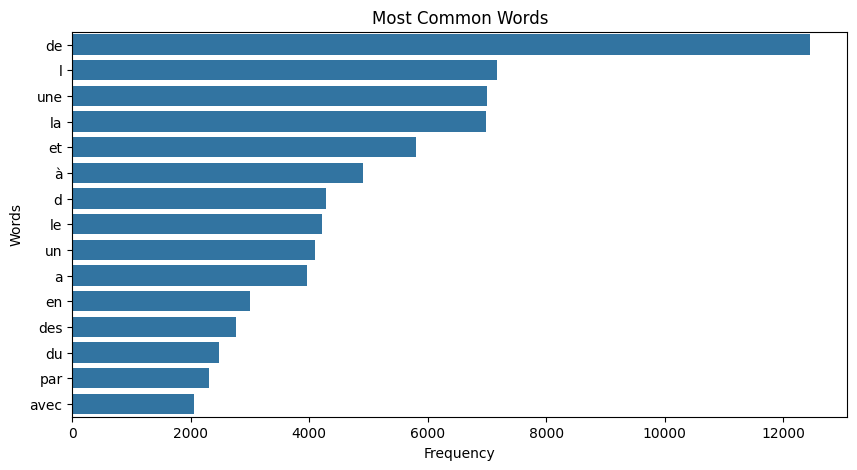

In [39]:
import matplotlib.pyplot as plt
import seaborn as sb
from collections import Counter
import string

punct = list(string.punctuation)
punct.append("’")
print(punct)

# ----------------------------
# 1. Flatten + remove punctuation
# ----------------------------
all_tokens = [
    token.lower()
    for row in df["tokens"]
    for token in row
    if token not in punct
]

# ----------------------------
# 2. Count frequencies
# ----------------------------
word_counts = Counter(all_tokens)

# ----------------------------
# 3. Get top N words
# ----------------------------
top_words = word_counts.most_common(15)

# ----------------------------
# 4. Split for plotting
# ----------------------------
words = [w for w, c in top_words]
counts = [c for w, c in top_words]

# ----------------------------
# 5. Plot
# ----------------------------
plt.figure(figsize=(10, 5))
sb.barplot(x=counts, y=words)

plt.title("Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.savefig("../Datasets/CAS/Charts/most_common_words_barplot.png")
plt.show()

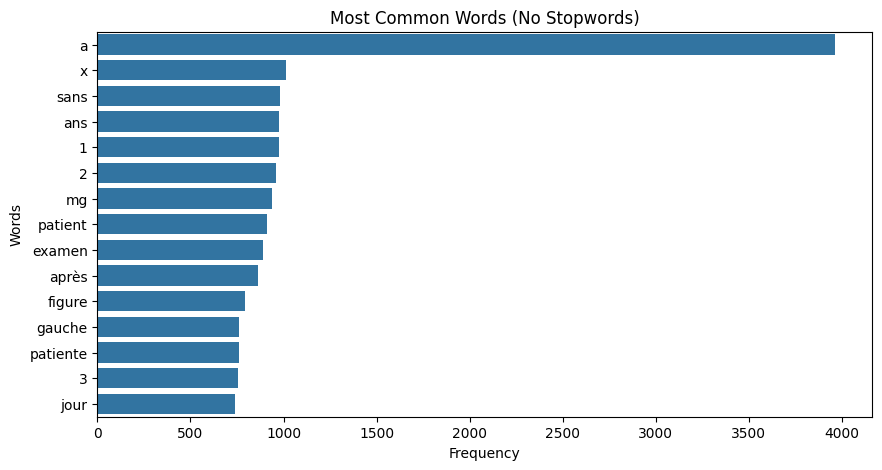

In [40]:
from nltk.corpus import stopwords

# ----------------------------
# 0. Stopwords + punctuation
# ----------------------------
punct = set(string.punctuation)
punct.add("’")

stop_words = set(stopwords.words("french"))

# ----------------------------
# 1. Flatten + clean tokens
# ----------------------------
all_tokens = [
    token.lower()
    for row in df["tokens"]
    for token in row
    if token.lower() not in punct
    and token.lower() not in stop_words
]

# ----------------------------
# 2. Count frequencies
# ----------------------------
word_counts = Counter(all_tokens)

# ----------------------------
# 3. Get top N words
# ----------------------------
top_words = word_counts.most_common(15)

# ----------------------------
# 4. Split for plotting
# ----------------------------
words = [w for w, c in top_words]
counts = [c for w, c in top_words]

# ----------------------------
# 5. Plot
# ----------------------------
plt.figure(figsize=(10, 5))
sb.barplot(x=counts, y=words)

plt.title("Most Common Words (No Stopwords)")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.savefig("../Datasets/CAS/Charts/most_common_words_no_stopwords_barplot.png")
plt.show()

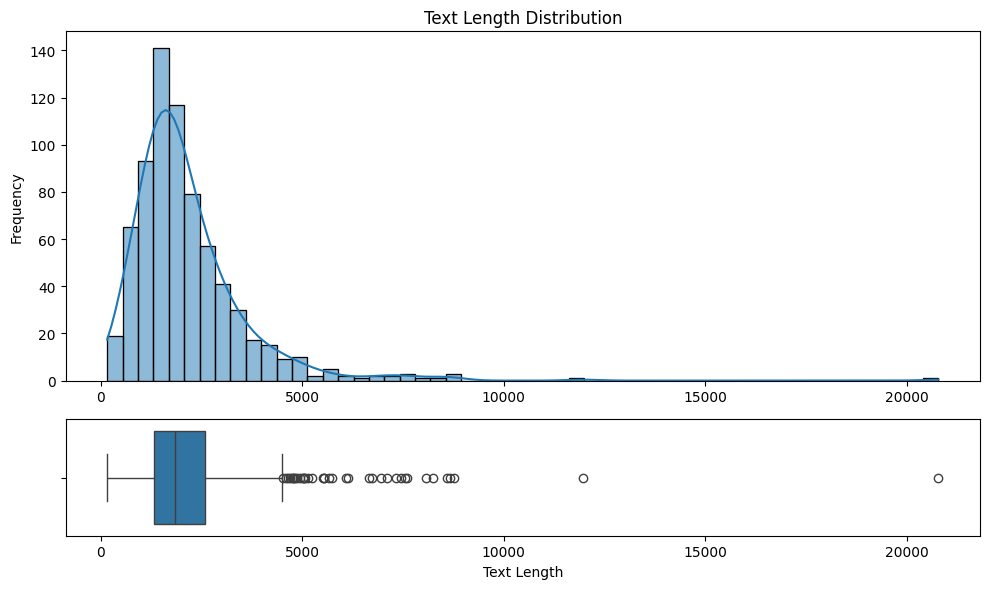

In [41]:
lengths = df["original_text"].str.len()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [3, 1]})

# ----------------------------
# Histogram (top)
# ----------------------------
sb.histplot(lengths, kde=True, ax=axes[0])
axes[0].set_title("Text Length Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Frequency")

# ----------------------------
# Boxplot (bottom)
# ----------------------------
sb.boxplot(x=lengths, ax=axes[1])
axes[1].set_xlabel("Text Length")

plt.tight_layout()
plt.savefig("../Datasets/CAS/Charts/text_length_distribution_hist_boxplot.png")
plt.show()

In [42]:
from collections import Counter
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

eda_df = df.copy()

unique_ner_dict = []
for i in range(1, len(ner_dict) - 1, 2):
    unique_ner_dict.append(ner_dict[i][2:])
print(unique_ner_dict)
print(len(unique_ner_dict))

new_col_names = [(e + "_wordcount") for e in unique_ner_dict]
eda_df[new_col_names] = None

def add_ner_wordcount_columns(df, ner_dict, unique_tags):

    # Create columns if missing
    for tag in unique_tags:

        col = f"{tag}_wordcount"

        if col not in df.columns:
            df[col] = 0

    # Process rows
    for idx, row in df.iterrows():

        ner_tags = row["ner_tags"]

        cleaned_tags = []

        for t in ner_tags:

            # Convert numeric tag -> string label
            if isinstance(t, (int, np.integer)):
                tag = ner_dict[t]
            else:
                tag = t

            # Ignore O
            if tag == "O":
                continue

            # Remove B- / I-
            cleaned = tag.split("-", 1)[1]

            cleaned_tags.append(cleaned)

        # Count tags
        counts = Counter(cleaned_tags)

        # Fill columns
        for tag in unique_tags:
            df.at[idx, f"{tag}_wordcount"] = counts.get(tag, 0)

    return df

eda_df = add_ner_wordcount_columns(df, ner_dict, unique_ner_dict)

num = eda_df.select_dtypes(include="number")
zero_cols = [c for c in num.columns if (num[c] == 0).all()]
eda_df = eda_df.drop(columns=zero_cols)

['infections', 'virales', 'parasitaires', 'tumeur', 'osteomusculaires', 'digestif', 'stomatognathique', 'respiratoire', 'ORL', 'nerveux', 'oeil', 'homme', 'femme', 'cardiovasculaires', 'hemopathies', 'genetique', 'peau', 'nutritionnelles', 'endocriniennes', 'immunitaire', 'environnement', 'animal', 'etatsosy', 'professionnelles', 'chimiques', 'blessures', 'pathologie', 'sosy', 'examen', 'valeur', 'traitement', 'substance', 'dose', 'mode', 'frequence', 'duree', 'date', 'moment', 'anatomie', 'localisation', 'genre', 'age', 'poids', 'taille', 'type', 'temperature', 'surface', 'origine', 'issue', 'specialite', 'voie', 'fonction', 'physiologie', 'nature', 'organisme', 'dispositif', 'classe', 'concentration', 'vitesse']
59


In [43]:
eda_df

,id,tokens,ner_tags,original_text,infections_wordcount,parasitaires_wordcount,tumeur_wordcount,osteomusculaires_wordcount,digestif_wordcount,respiratoire_wordcount,ORL_wordcount,nerveux_wordcount,oeil_wordcount,homme_wordcount,femme_wordcount,cardiovasculaires_wordcount,hemopathies_wordcount,genetique_wordcount,peau_wordcount,nutritionnelles_wordcount,endocriniennes_wordcount,immunitaire_wordcount,etatsosy_wordcount,chimiques_wordcount,blessures_wordcount,pathologie_wordcount,sosy_wordcount,examen_wordcount,valeur_wordcount,traitement_wordcount,substance_wordcount,dose_wordcount,mode_wordcount,frequence_wordcount,duree_wordcount,date_wordcount,moment_wordcount,anatomie_wordcount,genre_wordcount,age_wordcount,poids_wordcount,taille_wordcount,origine_wordcount,issue_wordcount,fonction_wordcount,organisme_wordcount,dispositif_wordcount
0,57,"[Mme, Lau, ., ,, 50, ans, ,, sans, antécédent,...","[81, 0, 0, 0, 83, 84, 0, 0, 0, 0, 0, 0, 0, 0, ...","Mme Lau., 50 ans, sans antécédent particulier,...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,15,14,0,0,0
1,205,"[C, ., F, ,, fille, de, 15, ans, a, présenté, ...","[0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, 0, 0, 95,...","C. F, fille de 15 ans a présenté pendant 3 moi...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,8,1,0,0,0
2,320,"[Nous, décrivons, ci, -, dessous, le, cas, d, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 81, 0, 83, 84, ...",Nous décrivons ci-dessous le cas d’un homme de...,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,104,23,0,8,0,0,6,0,0,0,5,2,1,2,0,0,0,24,0,0,0
3,530,"[Le, dernier, cas, concerne, un, homme, de, 42...","[0, 0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, 0, 0, ...",Le dernier cas concerne un homme de 42 ans aux...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,20,19,0,0,0
4,25,"[Mme, K, ., K, ., ., ., ,, 33, ans, a, été, re...","[81, 0, 0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, 0, ...","Mme K. K..., 33 ans a été reçue en consultatio...",2,0,0,0,0,0,0,0,0,18,0,0,0,0,0,0,0,0,2,0,0,0,51,9,0,28,0,0,4,4,3,0,5,0,1,2,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,133,"[Il, s, ’, agit, d, ’, une, femme, de, 56, ans...","[0, 0, 0, 0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, ...","Il s’agit d’une femme de 56 ans, qui s’est pré...",2,0,0,0,2,0,0,0,0,0,5,2,0,0,0,3,0,2,4,1,0,2,160,42,0,14,3,2,2,2,2,12,5,0,1,2,0,0,5,17,0,0,0
140,293,"[Madame, B, ., M, ., ,, âgée, de, 47, ans, ,, ...","[81, 0, 0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, 0, ...","Madame B. M., âgée de 47 ans, a été vue initia...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,7,17,0,0,0
141,42,"[Il, s, ’, agit, d, ’, une, patiente, âgée, de...","[0, 0, 0, 0, 0, 0, 0, 81, 0, 0, 83, 84, 0, 0, ...","Il s’agit d’une patiente âgée de 78 ans, sans ...",0,0,0,0,8,0,0,0,0,0,14,3,0,0,13,0,0,0,2,0,0,20,142,58,4,38,0,0,3,0,0,7,7,0,1,2,0,0,31,1,0,0,0
142,109,"[Un, homme, âgé, de, 19, ans, a, été, admis, d...","[0, 81, 0, 0, 83, 84, 0, 0, 0, 0, 0, 0, 0, 95,...",Un homme âgé de 19 ans a été admis dans notre ...,0,0,0,0,0,0,0,0,0,5,0,0,1,0,0,0,0,0,8,0,0,14,161,27,0,2,9,2,0,0,4,0,7,0,1,2,0,0,3,1,0,0,0


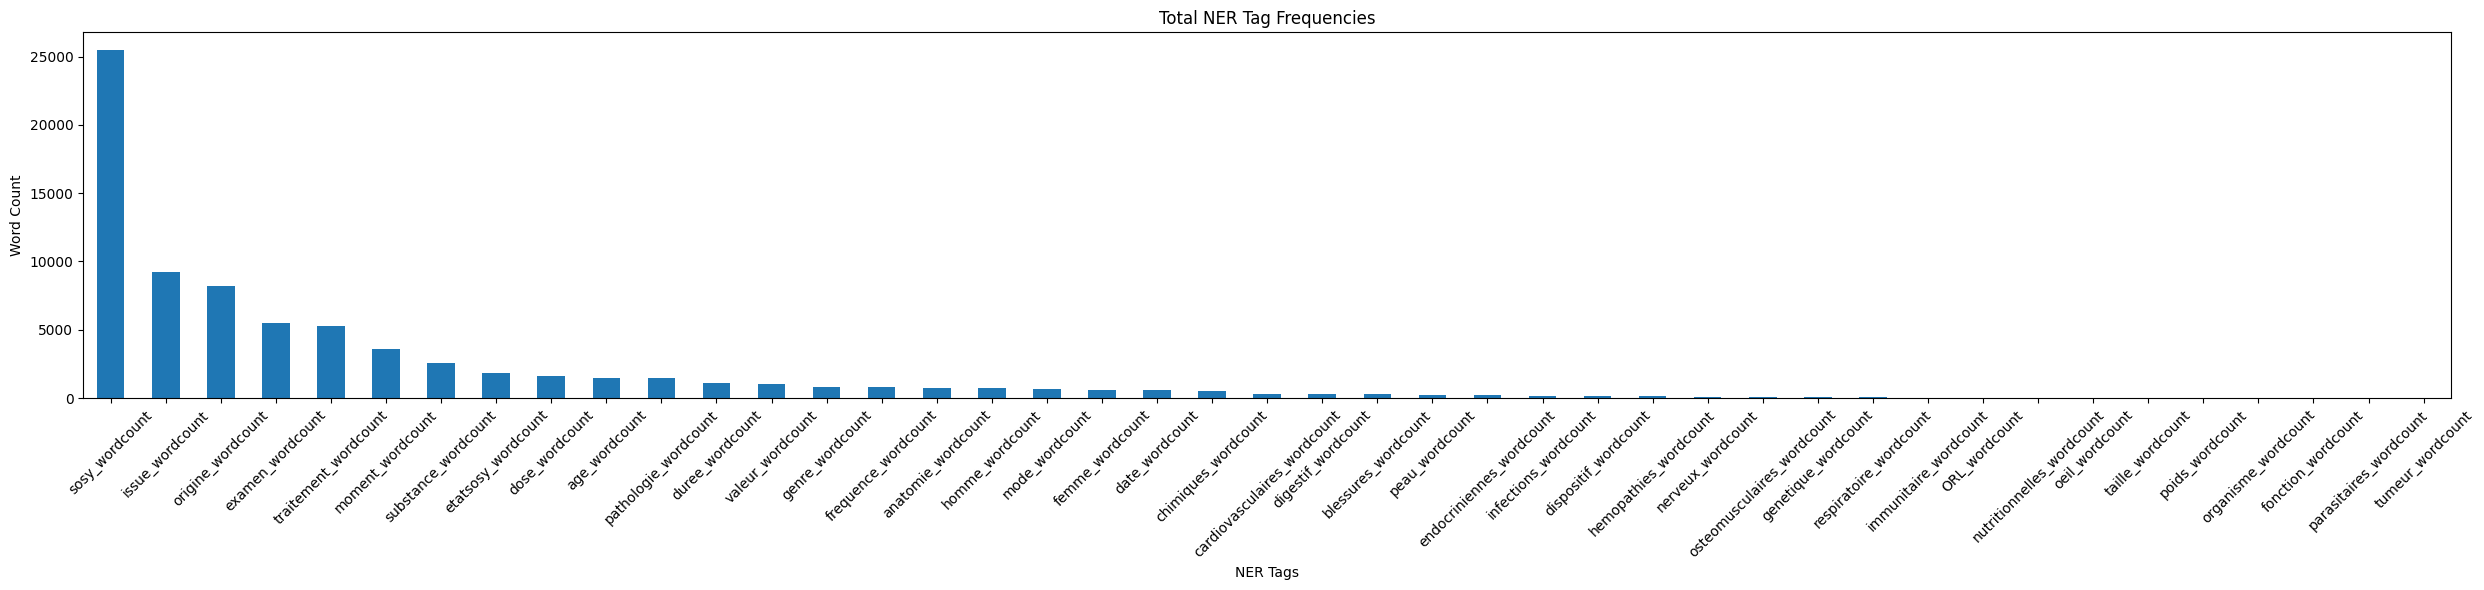

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# Columns like disease_wordcount, symptom_wordcount ...
tag_columns = [col for col in eda_df.columns if col.endswith("_wordcount")]

# Total occurrences
totals = eda_df[tag_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(25, 6))
totals.plot(kind="bar")

plt.title("Total NER Tag Frequencies")
plt.xlabel("NER Tags")
plt.ylabel("Word Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../Datasets/CAS/Charts/ner_tag_total_frequencies_barplot.png")
plt.show()

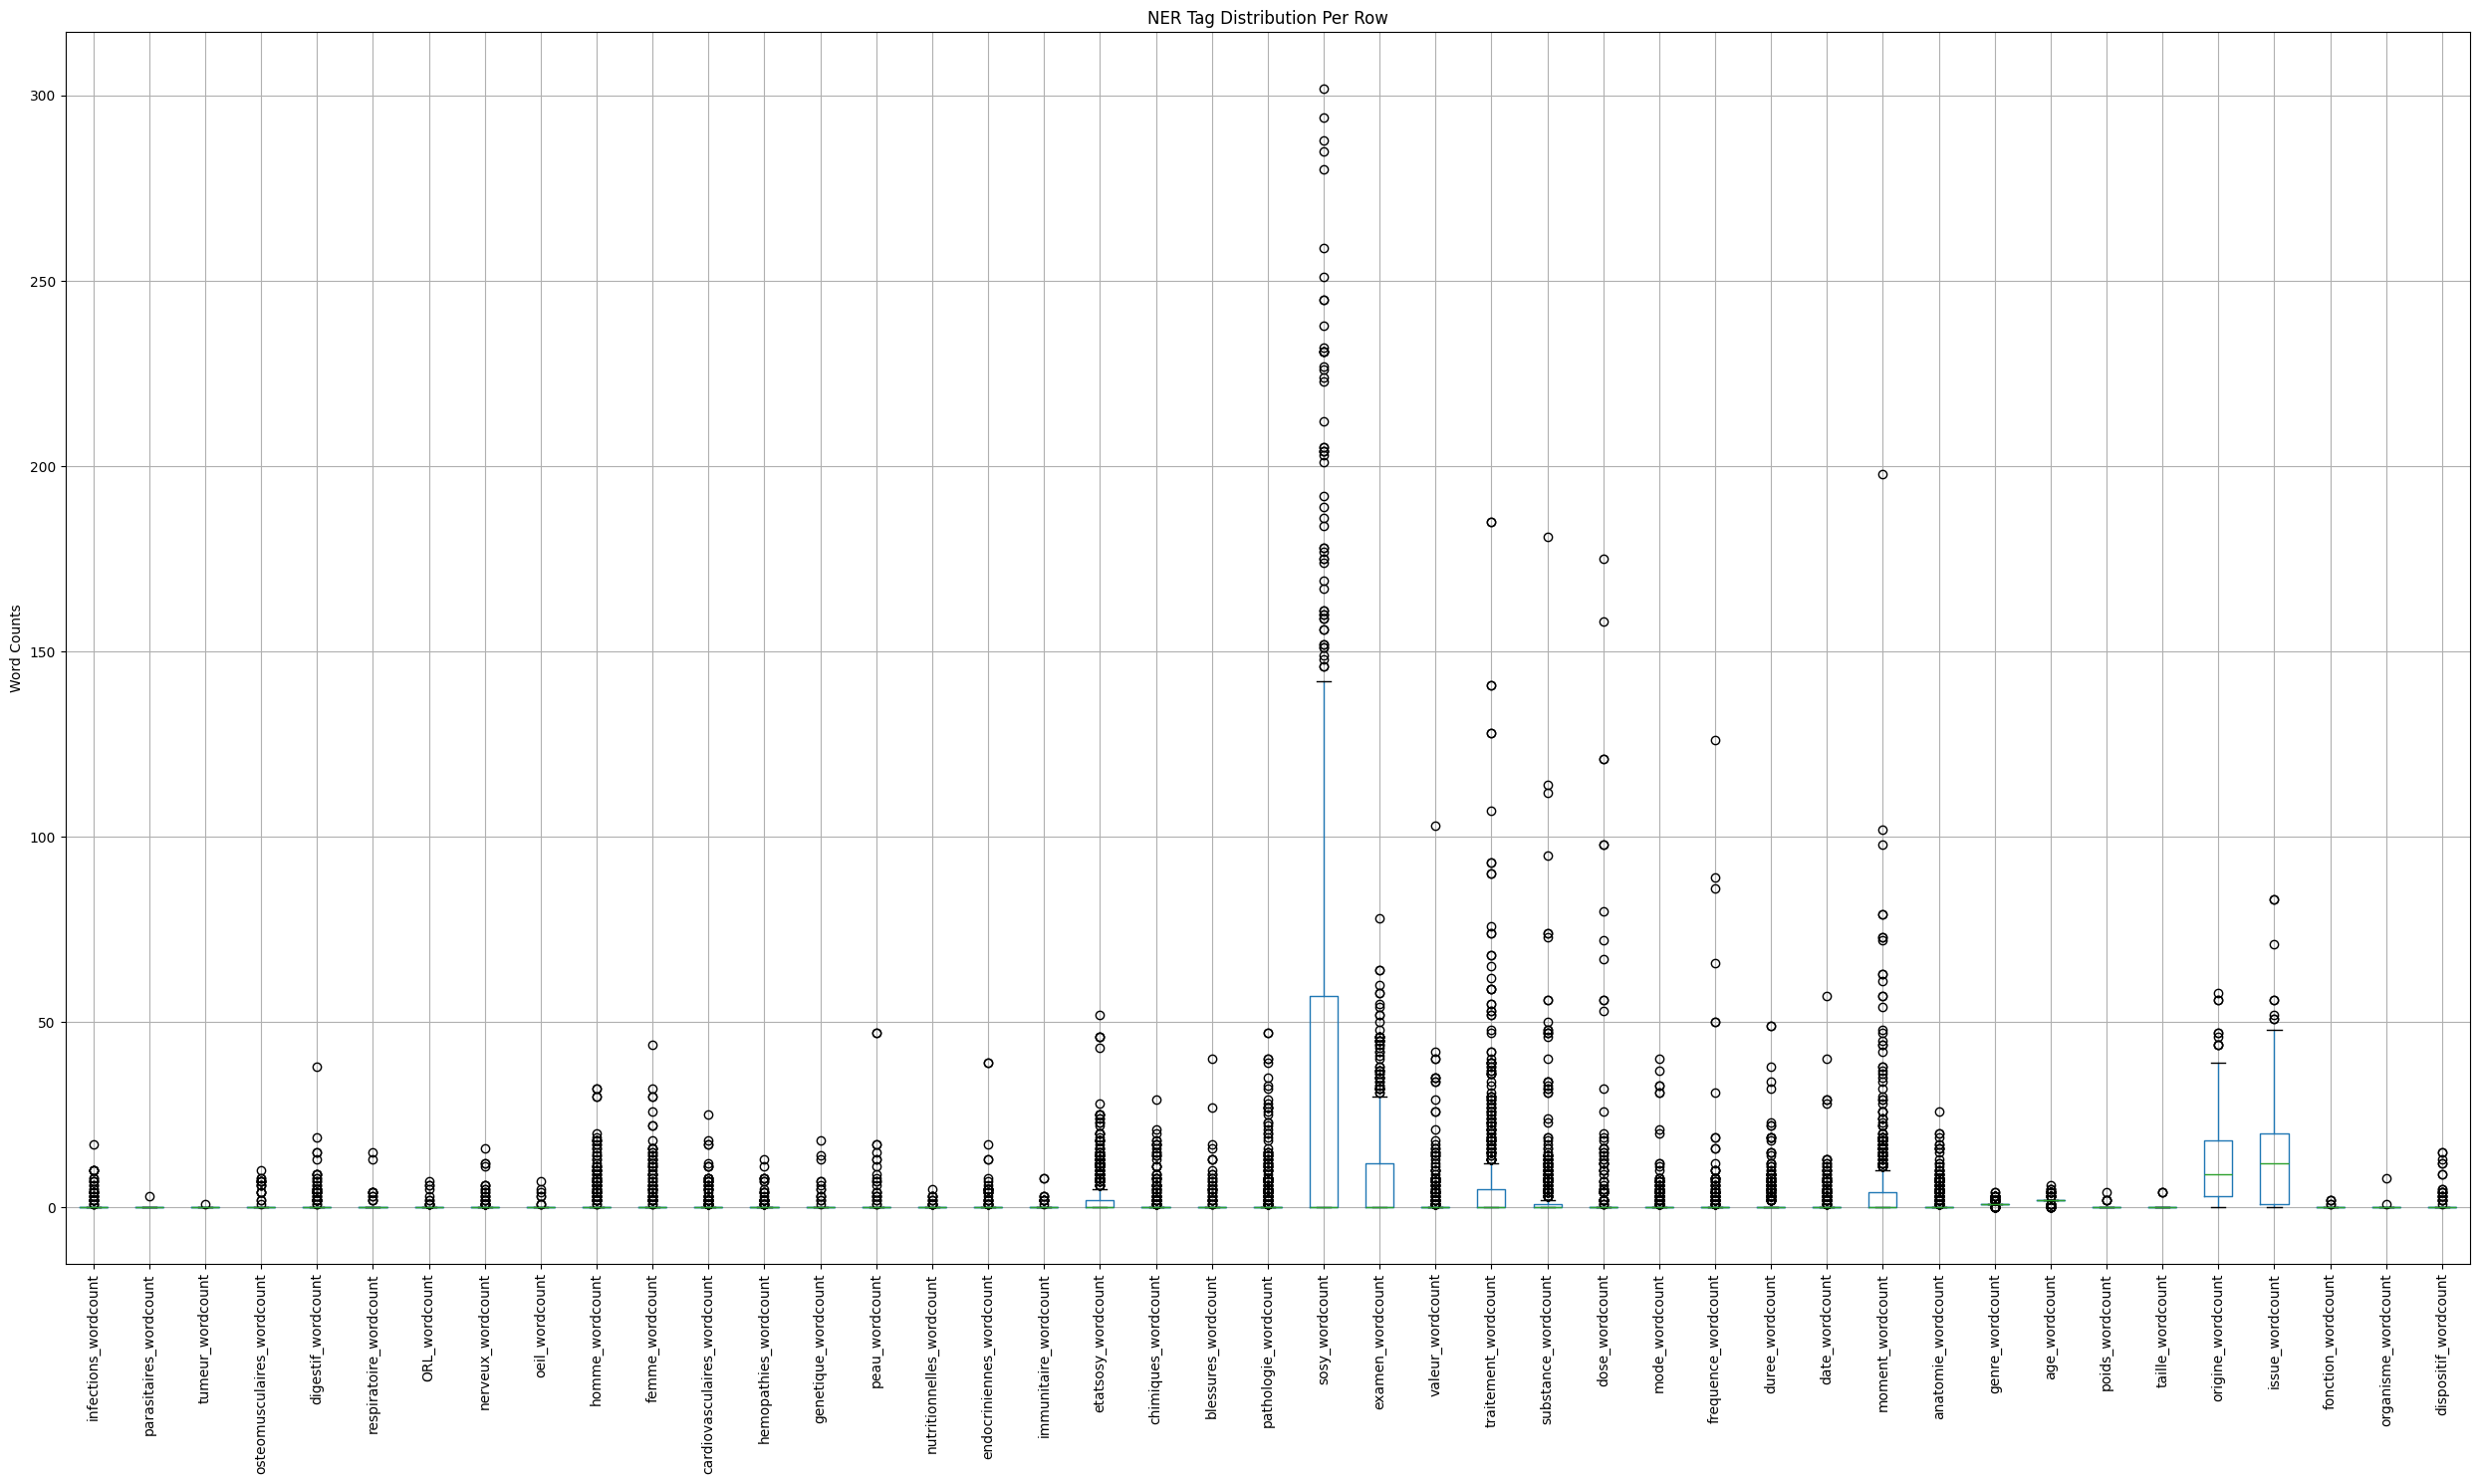

In [45]:
plt.figure(figsize=(25, 15))

eda_df[tag_columns].boxplot(rot=90)

plt.title("NER Tag Distribution Per Row")
plt.ylabel("Word Counts")

plt.tight_layout()
plt.savefig("../Datasets/CAS/Charts/ner_tag_distribution_per_row_boxplot.png")
plt.show()

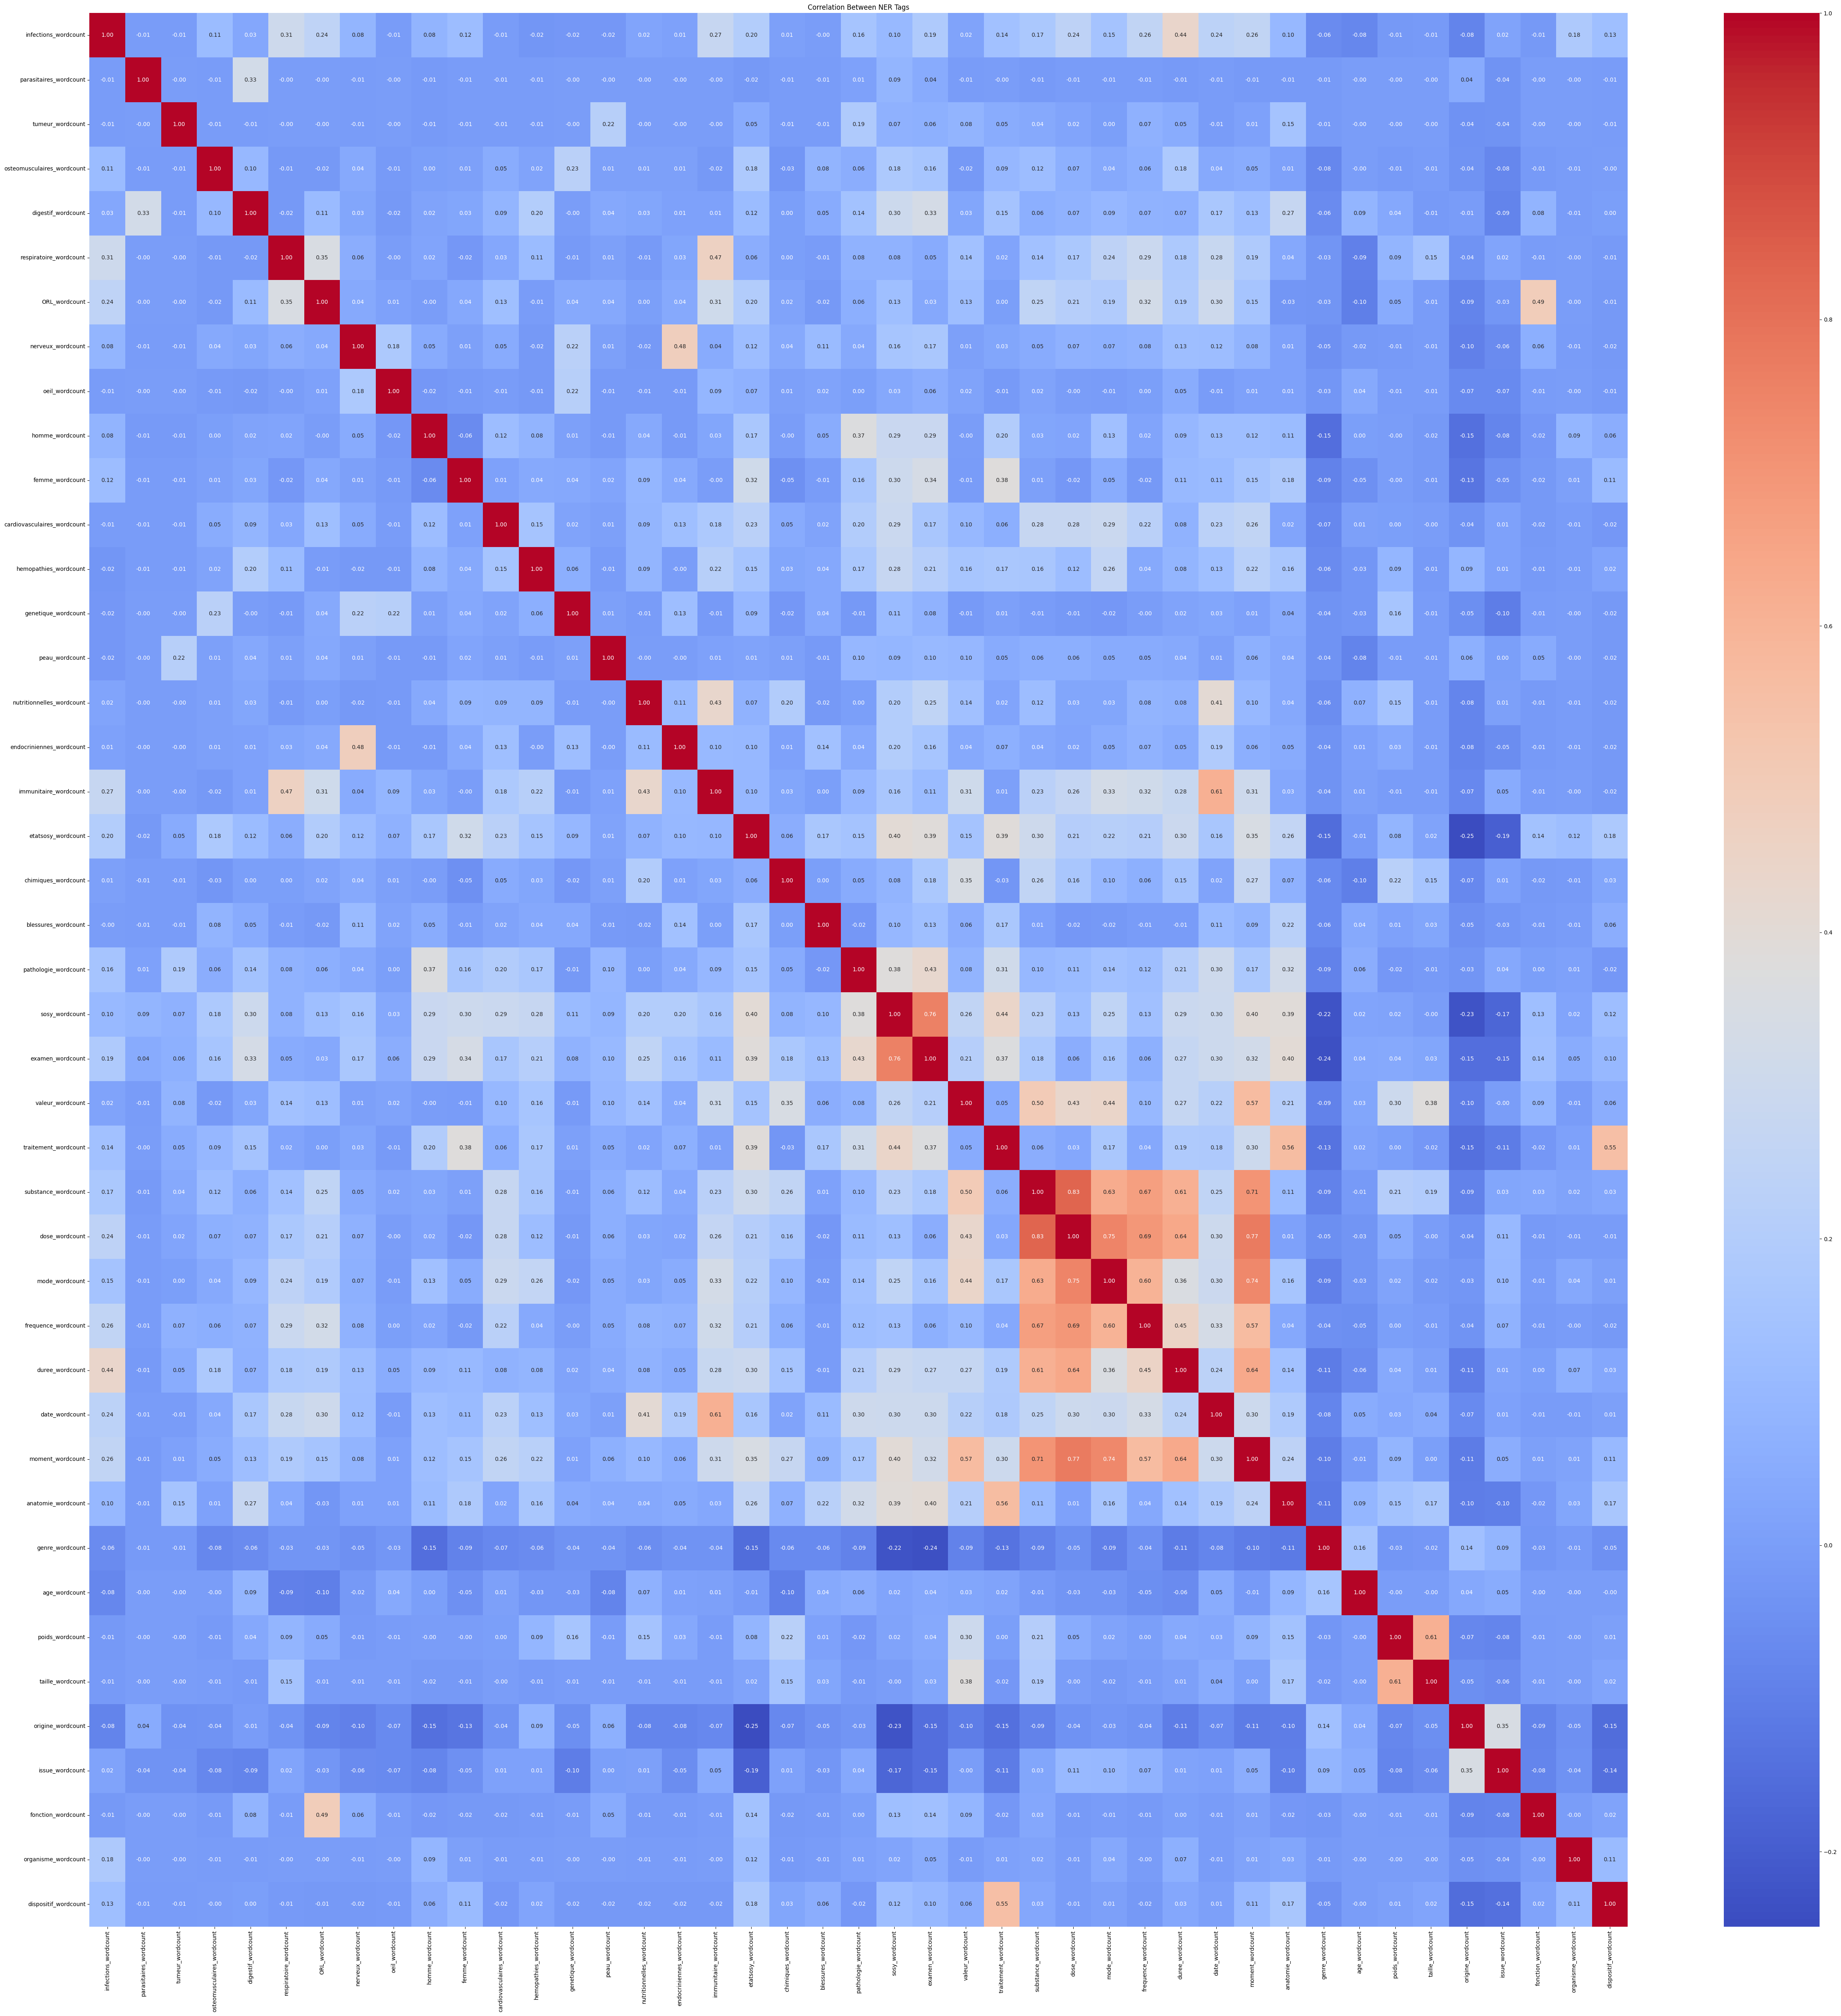

In [46]:
import seaborn as sns

corr = eda_df[tag_columns].corr()

plt.figure(figsize=(50, 50))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between NER Tags")

plt.tight_layout()
plt.savefig("../Datasets/CAS/Charts/ner_tag_correlation_heatmap.png")
plt.show()

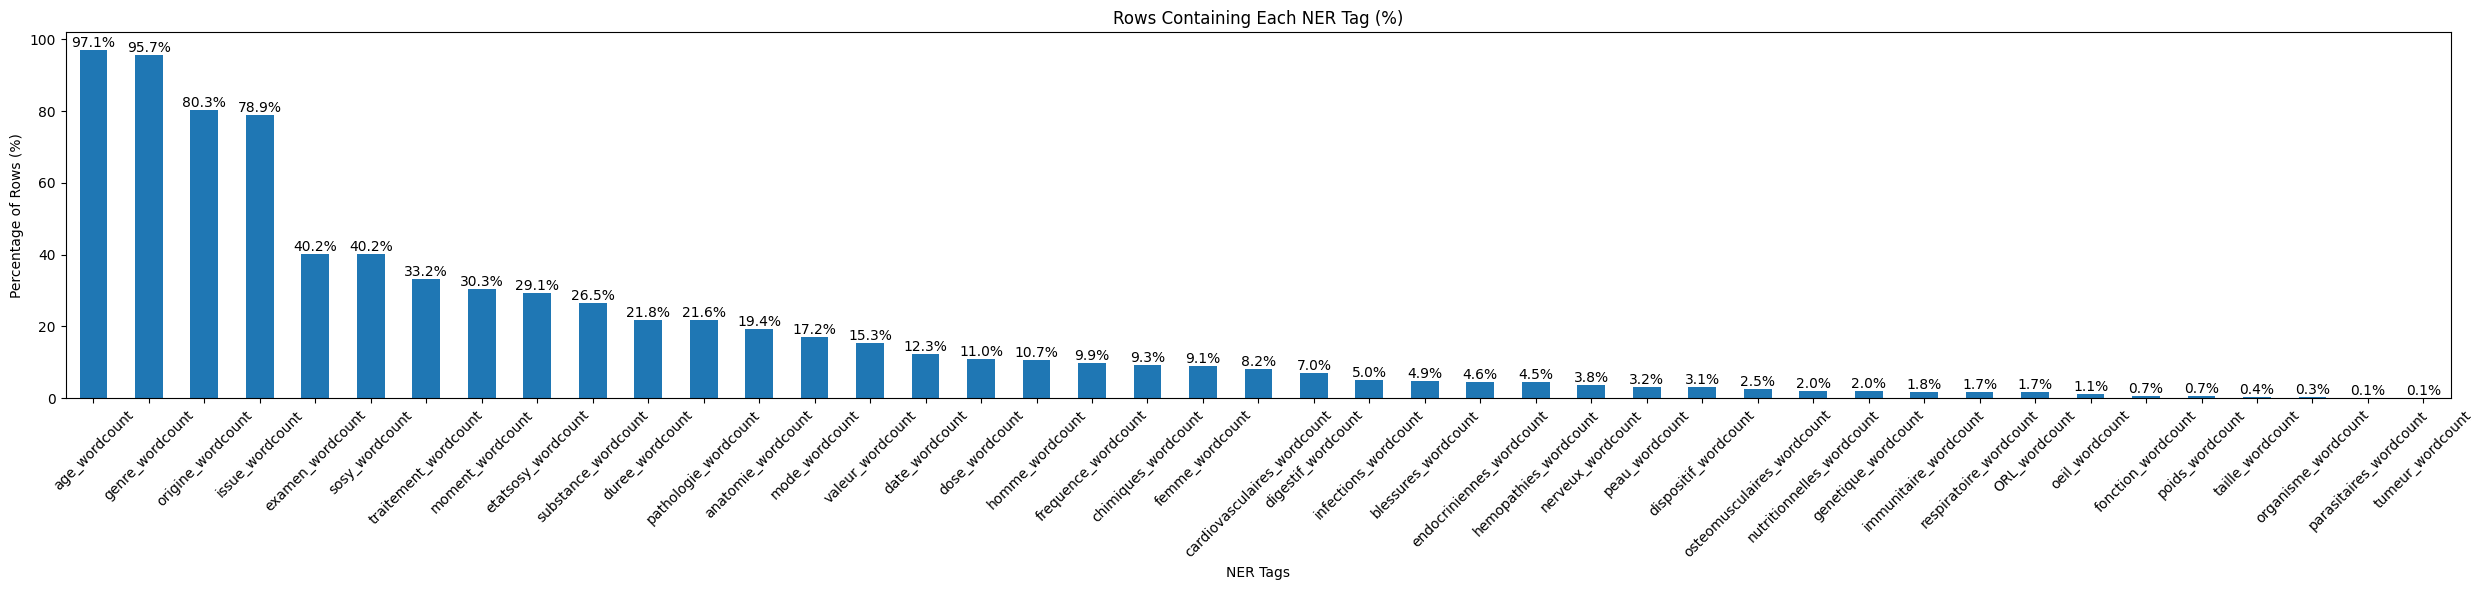

In [47]:
import matplotlib.pyplot as plt

n_rows = len(eda_df)

presence = (eda_df[tag_columns] > 0).sum()
presence_pct = (presence / n_rows) * 100
presence_pct = presence_pct.sort_values(ascending=False)

plt.figure(figsize=(25, 6))

ax = presence_pct.plot(kind="bar")

# Add values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Rows Containing Each NER Tag (%)")
plt.xlabel("NER Tags")
plt.ylabel("Percentage of Rows (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../Datasets/CAS/Charts/ner_tag_presence_percentage_barplot.png")
plt.show()

In [48]:
# plt.figure(figsize=(10, 5))

# eda_df["total_entities"].hist(bins=40)

# plt.title("Total Entities Per Row")
# plt.xlabel("Entity Count")
# plt.ylabel("Frequency")

# plt.show()

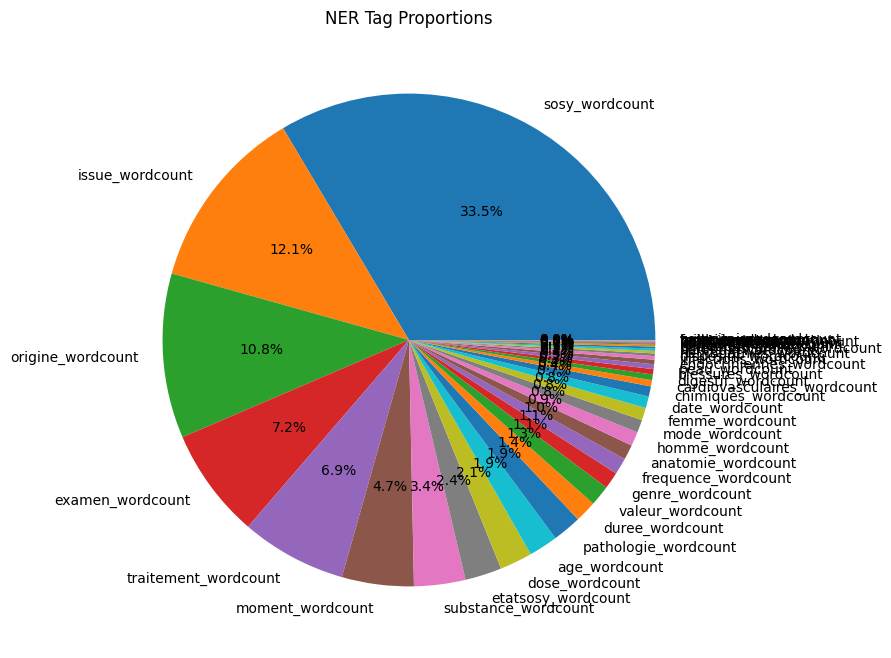

In [49]:
plt.figure(figsize=(8, 8))

totals.plot(kind="pie", autopct="%1.1f%%")

plt.title("NER Tag Proportions")
plt.savefig("../Datasets/CAS/Charts/ner_tag_proportions_pieplot.png")
plt.show()

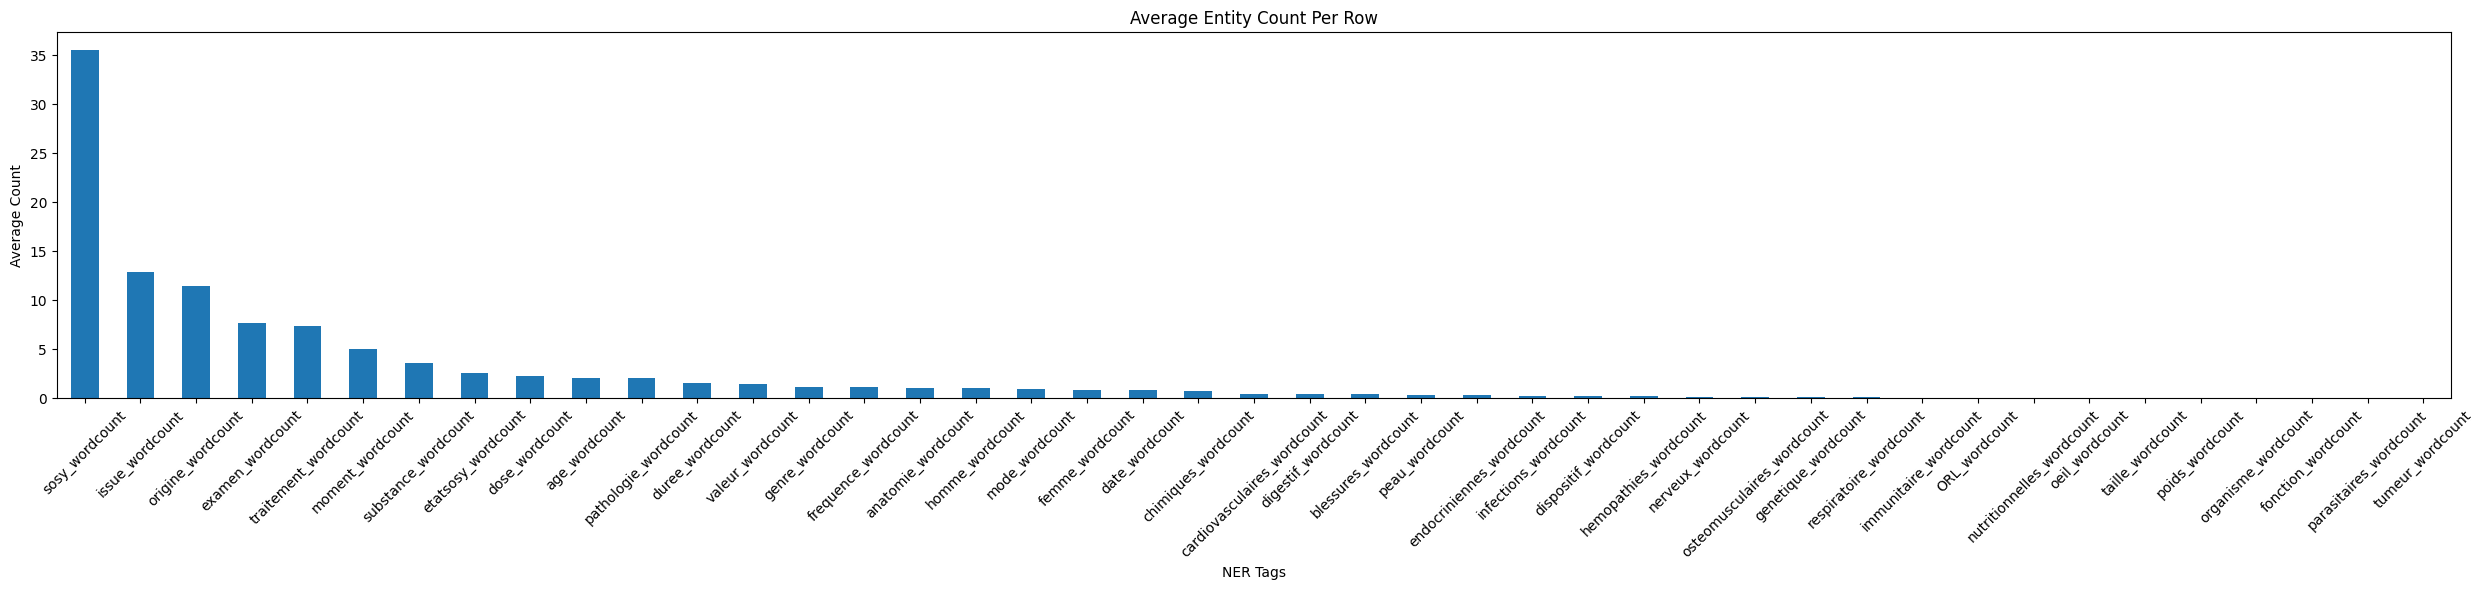

In [50]:
avg_counts = eda_df[tag_columns].mean().sort_values(ascending=False)

plt.figure(figsize=(25, 6))

avg_counts.plot(kind="bar")

plt.title("Average Entity Count Per Row")
plt.xlabel("NER Tags")
plt.ylabel("Average Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../Datasets/CAS/Charts/average_ner_tag_count_per_row_barplot.png")
plt.show()

In [51]:
df

,id,tokens,ner_tags,original_text,infections_wordcount,virales_wordcount,parasitaires_wordcount,tumeur_wordcount,osteomusculaires_wordcount,digestif_wordcount,stomatognathique_wordcount,respiratoire_wordcount,ORL_wordcount,nerveux_wordcount,oeil_wordcount,homme_wordcount,femme_wordcount,cardiovasculaires_wordcount,hemopathies_wordcount,genetique_wordcount,peau_wordcount,nutritionnelles_wordcount,endocriniennes_wordcount,immunitaire_wordcount,environnement_wordcount,animal_wordcount,etatsosy_wordcount,professionnelles_wordcount,chimiques_wordcount,blessures_wordcount,pathologie_wordcount,sosy_wordcount,examen_wordcount,valeur_wordcount,traitement_wordcount,substance_wordcount,dose_wordcount,mode_wordcount,frequence_wordcount,duree_wordcount,date_wordcount,moment_wordcount,anatomie_wordcount,localisation_wordcount,genre_wordcount,age_wordcount,poids_wordcount,taille_wordcount,type_wordcount,temperature_wordcount,surface_wordcount,origine_wordcount,issue_wordcount,specialite_wordcount,voie_wordcount,fonction_wordcount,physiologie_wordcount,nature_wordcount,organisme_wordcount,dispositif_wordcount,classe_wordcount,concentration_wordcount,vitesse_wordcount
0,57,"[Mme, Lau, ., ,, 50, ans, ,, sans, antécédent,...","[81, 0, 0, 0, 83, 84, 0, 0, 0, 0, 0, 0, 0, 0, ...","Mme Lau., 50 ans, sans antécédent particulier,...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,15,14,0,0,0,0,0,0,0,0,0,0
1,205,"[C, ., F, ,, fille, de, 15, ans, a, présenté, ...","[0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, 0, 0, 95,...","C. F, fille de 15 ans a présenté pendant 3 moi...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,8,1,0,0,0,0,0,0,0,0,0,0
2,320,"[Nous, décrivons, ci, -, dessous, le, cas, d, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 81, 0, 83, 84, ...",Nous décrivons ci-dessous le cas d’un homme de...,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,104,23,0,8,0,0,6,0,0,0,5,2,0,1,2,0,0,0,0,0,0,24,0,0,0,0,0,0,0,0,0,0
3,530,"[Le, dernier, cas, concerne, un, homme, de, 42...","[0, 0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, 0, 0, ...",Le dernier cas concerne un homme de 42 ans aux...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,20,19,0,0,0,0,0,0,0,0,0,0
4,25,"[Mme, K, ., K, ., ., ., ,, 33, ans, a, été, re...","[81, 0, 0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, 0, ...","Mme K. K..., 33 ans a été reçue en consultatio...",2,0,0,0,0,0,0,0,0,0,0,18,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,51,9,0,28,0,0,4,4,3,0,5,0,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,133,"[Il, s, ’, agit, d, ’, une, femme, de, 56, ans...","[0, 0, 0, 0, 0, 0, 0, 81, 0, 83, 84, 0, 0, 0, ...","Il s’agit d’une femme de 56 ans, qui s’est pré...",2,0,0,0,0,2,0,0,0,0,0,0,5,2,0,0,0,3,0,2,0,0,4,0,1,0,2,160,42,0,14,3,2,2,2,2,12,5,0,0,1,2,0,0,0,0,0,5,17,0,0,0,0,0,0,0,0,0,0
140,293,"[Madame, B, ., M, ., ,, âgée, de, 47, ans, ,, ...","[81, 0, 0, 0, 0, 0, 0, 0, 83, 84, 0, 0, 0, 0, ...","Madame B. M., âgée de 47 ans, a été vue initia...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,7,17,0,0,0,0,0,0,0,0,0,0
141,42,"[Il, s, ’, agit, d, ’, une, patiente, âgée, de...","[0, 0, 0, 0, 0, 0, 0, 81, 0, 0, 83, 84, 0, 0, ...","Il s’agit d’une patiente âgée de 78 ans, sans ...",0,0,0,0,0,8,0,0,0,0,0,0,14,3,0,0,13,0,0,0,0,0,2,0,0,0,20,142,58,4,38,0,0,3,0,0,7,7,0,0,1,2,0,0,0,0,0,31,1,0,0,0,0,0,0,0,0,0,0
142,109,"[Un, homme, âgé, de, 19, ans, a, été, admis, d...","[0, 81, 0, 0, 83, 84, 0, 0, 0, 0, 0, 0, 0, 95,...",Un homme âgé de 19 ans a été admis dans notre ...,0,0,0,0,0,0,0,0,0,0,0,5,0,0,1,0,0,0,0,0,0,0,8,0,0,0,14,161,27,0,2,9,2,0,0,4,0,7,0,0,1,2,0,0,0,0,0,3,1,0,0,0,0,0,0,0,0,0,0


In [52]:
df[["id", "tokens", "ner_tags"]].to_parquet(r"../Datasets/CAS/CAS_all.parquet")